# Reto 1: Humano vs Máquina - La Batalla de los Pingüinos 🐧

## Expedición Antártica Palmer - Clasificación de Especies

---

```
                                    .-.
                                   /   \
                                  |  O  |
                                  |  _  |
                                 /|     |\
                                / |     | \
    ╔═══════════════════════╗  /  |     |  \
    ║  EXPEDICIÓN PALMER    ║ /   |_____|   \
    ║  ANTÁRTIDA 2026       ║/    /     \    \
    ║                       ║    /       \
    ║  MISIÓN: Clasificar   ║   /  ADELIE \
    ║  especies de          ║  /  CHINSTRAP\
    ║  pingüinos            ║ /   GENTOO    \
    ╚═══════════════════════╝/_______________\
           ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
                    OCÉANO ANTÁRTICO
```

---

## 📋 Contexto de la Misión

**Fecha:** Febrero 2026  
**Ubicación:** Estación Palmer, Archipiélago Palmer, Antártida  
**Equipo:** Tú, como biólogo/a de campo recién integrado/a

https://es.wikipedia.org/wiki/Base_Palmer

### La Situación

Has sido reclutado/a para una expedición científica en la **Estación Palmer**, ubicada en la Península Antártica. El equipo de investigación lleva años monitoreando tres especies de pingüinos:

```
    ADELIE                CHINSTRAP              GENTOO
    ══════                ═════════              ══════
      ▄▄                     ▄▄                    ▄▄
    ▄████▄                 ▄████▄                ▄████▄
   ██○██○██               ██○██○██              ██○██○██
    ██▄▄██                 ██━━██                ██▄▄██
     ████                   ████                  ████
    ██  ██                 ██  ██                ██  ██
    
   Ojos blancos          Línea en             Mancha blanca
   característicos       la barbilla          en la cabeza
```

### El Desafío

El sistema automático de clasificación de la estación falló, y hay **344 pingüinos** que necesitan ser clasificados antes de que termine la temporada de investigación.

La Dra. Kristen Gorman, líder del proyecto, te propone un reto:

> *"Diseña tus propias reglas de clasificación basándote en las medidas físicas de los pingüinos. Luego compararemos tu sistema con un modelo de Machine Learning. ¿Quién ganará: el humano o la máquina?"*

---

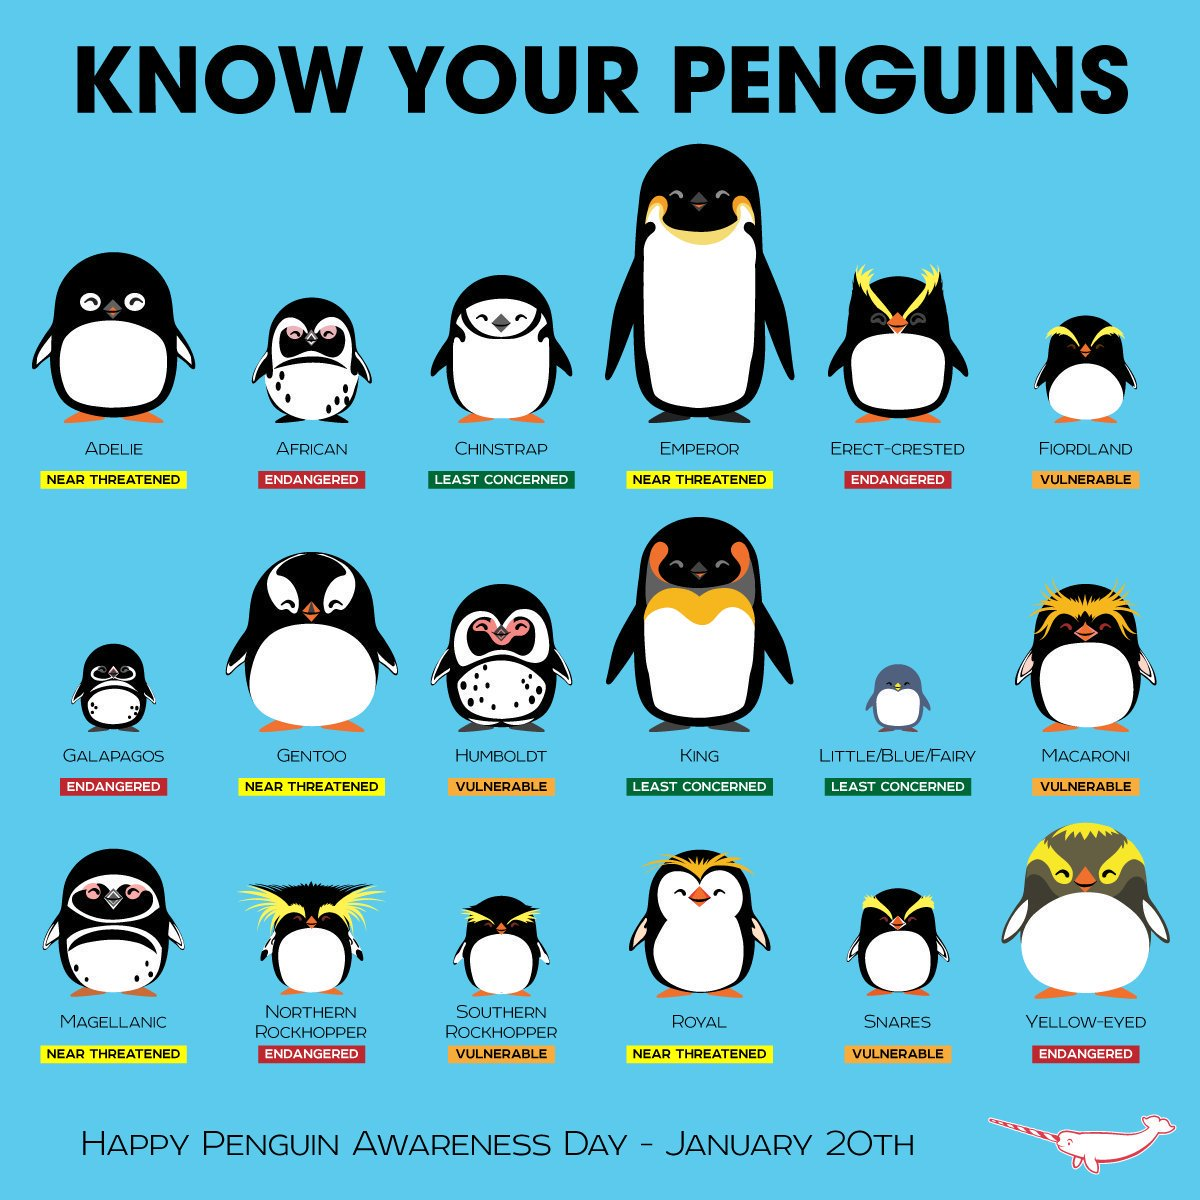

## 🎯 Objetivos del Reto

Al completar este reto, habrás:

1. ✅ Explorado un dataset real de pingüinos de la Antártida
2. ✅ Creado reglas de clasificación **manuales** (enfoque tradicional)
3. ✅ Entrenado un modelo de Machine Learning (enfoque ML)
4. ✅ Comparado ambos enfoques y reflexionado sobre las diferencias
5. ✅ Experimentado de primera mano por qué ML es tan poderoso

---

## 📊 Sistema de Puntuación

| Parte | Descripción | Puntos |
|-------|-------------|--------|
| **Parte 1** | Exploración y comprensión del dataset | 15 pts |
| **Parte 2** | Diseño de reglas manuales de clasificación | 25 pts |
| **Parte 3** | Implementación y evaluación del clasificador humano | 20 pts |
| **Parte 4** | Entrenamiento del modelo de Machine Learning | 20 pts |
| **Parte 5** | Batalla final y análisis comparativo | 20 pts |
| **TOTAL** | | **100 pts** |
| **Bonus** | Mejora tu clasificador humano después de ver los errores | +10 pts |

---

## 🔧 Configuración Inicial

Ejecuta esta celda para preparar tu estación de trabajo científica.

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE LA ESTACIÓN PALMER - NO MODIFICAR
# ═══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

# Colores oficiales de cada especie (inspirados en sus características)
COLORES_ESPECIES = {
    'Adelie': '#FF6B6B',      # Rojo coral
    'Chinstrap': '#4ECDC4',   # Turquesa
    'Gentoo': '#996CAE'       # Morado eléctrico
}

print("╔═══════════════════════════════════════════════════════════════╗")
print("║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║")
print("║                                                               ║")
print("║   Bibliotecas cargadas correctamente                          ║")
print("║   Modo: HUMANO VS MÁQUINA                                     ║")
print("║                                                               ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║     🐧 ESTACIÓN PALMER - SISTEMA DE CLASIFICACIÓN v2.0 🐧     ║
║                                                               ║
║   Bibliotecas cargadas correctamente                          ║
║   Modo: HUMANO VS MÁQUINA                                     ║
║                                                               ║
╚═══════════════════════════════════════════════════════════════╝


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CARGAR DATOS DE CAMPO - Dataset Palmer Penguins
# ═══════════════════════════════════════════════════════════════════════════

# Cargar el dataset de pingüinos (viene con seaborn)
df_original = sns.load_dataset('penguins')

# Eliminar filas con valores nulos para simplificar
df = df_original.dropna().reset_index(drop=True)

print("📡 Transmisión recibida desde Estación Palmer...")
print("")
print(f"   📊 Registros de pingüinos cargados: {len(df)}")
print(f"   🏝️  Islas monitoreadas: {df['island'].nunique()}")
print(f"   🐧 Especies identificadas: {df['species'].nunique()}")
print("")
print("   Distribución por especie:")
for species in df['species'].unique():
    count = (df['species'] == species).sum()
    print(f"      • {species}: {count} individuos")

print("")
print("✅ Datos listos para análisis")

📡 Transmisión recibida desde Estación Palmer...

   📊 Registros de pingüinos cargados: 333
   🏝️  Islas monitoreadas: 3
   🐧 Especies identificadas: 3

   Distribución por especie:
      • Adelie: 146 individuos
      • Chinstrap: 68 individuos
      • Gentoo: 119 individuos

✅ Datos listos para análisis


---

# PARTE 1: Exploración del Dataset (15 puntos)

## 📖 Conociendo a los Pingüinos

Antes de crear reglas de clasificación, necesitas **entender los datos**. Un buen científico siempre explora antes de actuar.

### Las Variables Disponibles

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    FICHA TÉCNICA DEL PINGÜINO                           │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│     ┌──────────┐                                                        │
│     │ ┌────┐   │◄──── bill_length_mm (largo del pico)                   │
│     │ │    │   │                                                        │
│     │ └────┘   │◄──── bill_depth_mm (profundidad/alto del pico)         │
│     │  ○  ○    │                                                        │
│     │   __     │                                                        │
│     │  ████    │                                                        │
│     │ ██████   │◄──── body_mass_g (masa corporal en gramos)             │
│     │  ████    │                                                        │
│     │ ▓▓  ▓▓   │◄──── flipper_length_mm (largo de la aleta)             │
│     └──────────┘                                                        │
│                                                                         │
│     + species (especie): Adelie, Chinstrap, Gentoo                      │
│     + island (isla): Torgersen, Biscoe, Dream                           │
│     + sex (sexo): male, female                                          │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
```

In [3]:
# Veamos las primeras filas del dataset
print("🔍 Primeros 10 registros del campo:")
print("="*80)
df.head(10)

🔍 Primeros 10 registros del campo:


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
5,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
6,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
7,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female
8,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male
9,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male


### Ejercicio 1.1: Estadísticas Básicas (5 puntos)

Calcula las estadísticas descriptivas del dataset usando `.describe()` y responde las preguntas.

In [4]:
# TU CÓDIGO AQUÍ: Muestra las estadísticas descriptivas del dataset
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


**Responde en esta celda:**

1. ¿Cuál es el rango de masa corporal (body_mass_g) de los pingüinos? (mínimo a máximo)
   - *Tu respuesta:* 2700-6300
2. ¿Cuál es la longitud promedio del pico (bill_length_mm)?
   - *Tu respuesta:* 43.992793
3. ¿Cuál es la longitud promedio de la aleta (flipper_length_mm)?
   - *Tu respuesta:* 200.966967

### Ejercicio 1.2: Estadísticas por Especie (10 puntos)

Ahora lo importante: ¿cómo se diferencian las especies? Calcula el **promedio de cada variable numérica para cada especie**.

In [5]:
# TU CÓDIGO AQUÍ: Calcula el promedio de cada variable agrupando por especie

columnas_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Escribe tu código aquí:
df[columnas_numericas].groupby(df["species"]).mean()


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


**Responde en esta celda:**

Basándote en los promedios por especie:

1. ¿Qué especie tiene el pico más largo en promedio?
   - *Tu respuesta:* Chinstrap

2. ¿Qué especie tiene las aletas más largas?
   - *Tu respuesta:* Gentoo

3. ¿Qué especie es la más pesada?
   - *Tu respuesta:* Gentoo

4. ¿Qué especie tiene el pico más profundo (bill_depth más alto)?
   - *Tu respuesta:* Chinstrap

### Visualización de Apoyo

Ejecuta la siguiente celda para ver gráficamente las diferencias entre especies. **Esto te ayudará a diseñar tus reglas.**

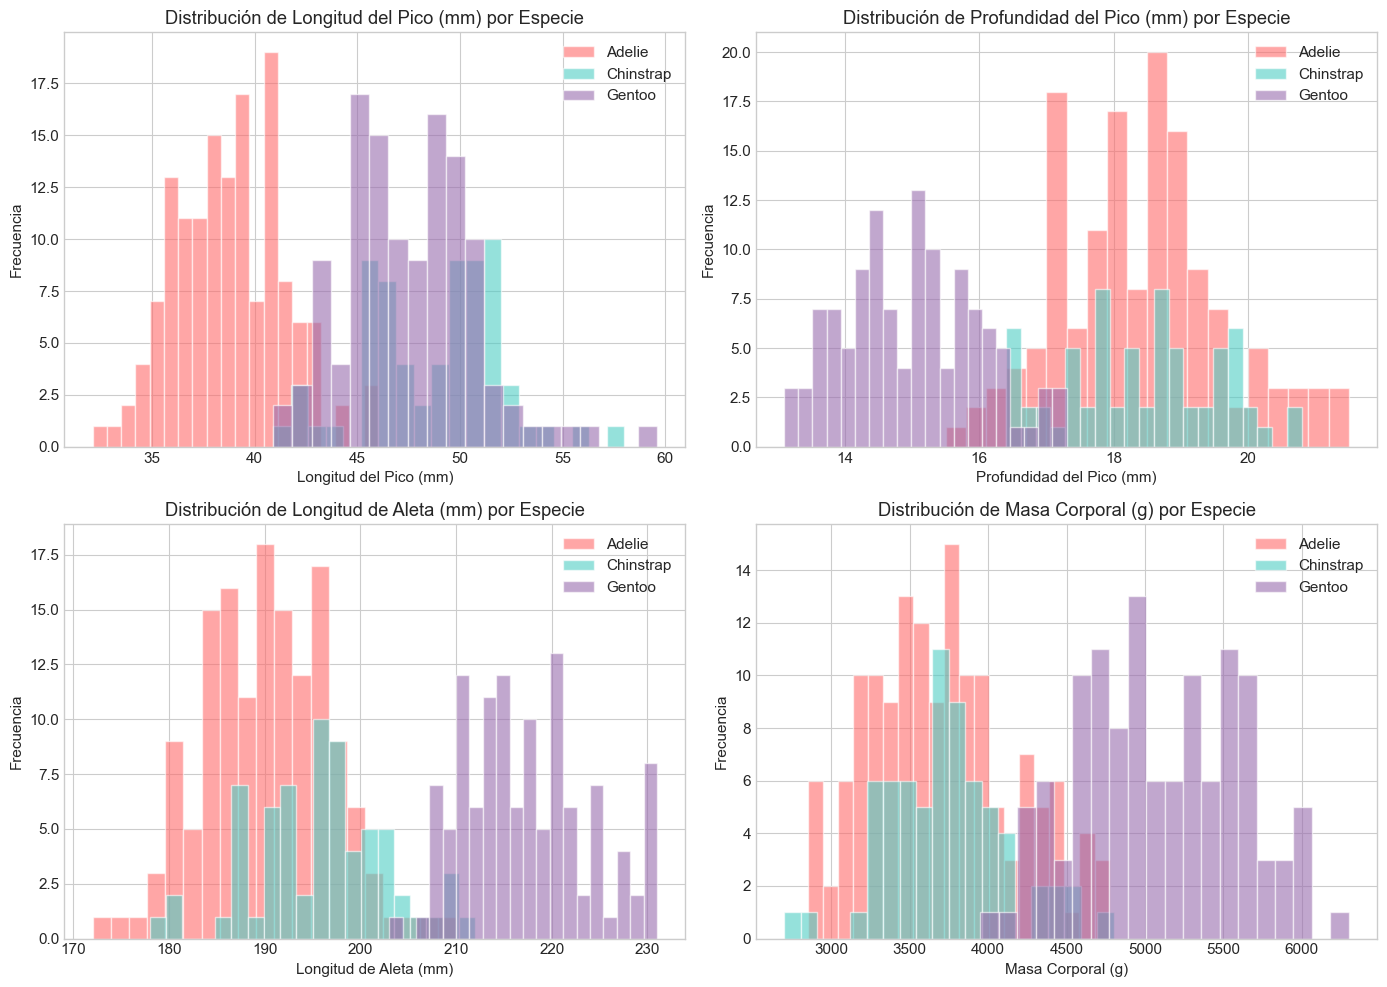


💡 OBSERVA: ¿Qué variables separan mejor las especies?
   Busca variables donde los histogramas NO se solapan mucho.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Diferencias entre especies
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

variables = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
titulos = ['Longitud del Pico (mm)', 'Profundidad del Pico (mm)', 
           'Longitud de Aleta (mm)', 'Masa Corporal (g)']

for ax, var, titulo in zip(axes.flat, variables, titulos):
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[var], alpha=0.6, label=species, 
                color=COLORES_ESPECIES[species], bins=20, edgecolor='white')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.set_title(f'Distribución de {titulo} por Especie')

plt.tight_layout()
plt.savefig('pinguinos_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 OBSERVA: ¿Qué variables separan mejor las especies?")
print("   Busca variables donde los histogramas NO se solapan mucho.")

'for species in df[\'species\'].unique():\n    subset = df[df[\'species\'] == species]\n    axes[1].scatter(subset[\'flipper_length_mm\'], subset[\'body_mass_g\'],\n                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)\naxes[1].set_xlabel(\'Longitud de Aleta (mm)\')\naxes[1].set_ylabel(\'Masa Corporal (g)\')\naxes[1].set_title(\'Aleta vs Masa por Especie\')\naxes[1].legend()\naxes[1].grid(True, alpha=0.3)\n\nplt.tight_layout()\nplt.savefig(\'pinguinos_scatter.png\', dpi=150, bbox_inches=\'tight\')\nplt.show()\n\nprint("\n💡 PISTA IMPORTANTE:")\nprint("   Observa la gráfica de la derecha (Aleta vs Masa).")\nprint("   ¿Puedes ver que una especie está claramente separada de las otras dos?")\nprint("   ¿Podrías dibujar una línea horizontal o vertical que la separe?")'

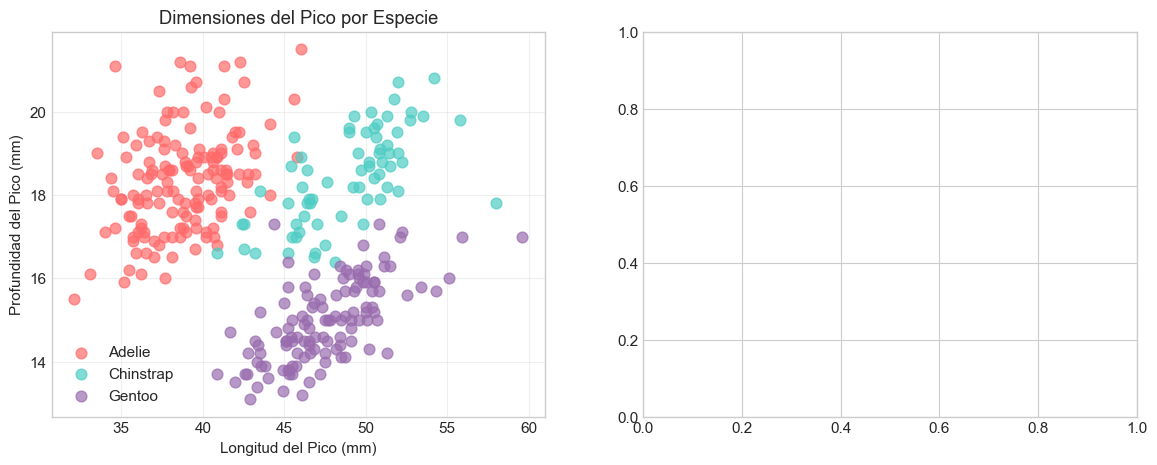

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# VISUALIZACIÓN: Scatter plot para encontrar fronteras de decisión
# ═══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Pico (longitud vs profundidad)
for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[0].scatter(subset['bill_length_mm'], subset['bill_depth_mm'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[0].set_xlabel('Longitud del Pico (mm)')
axes[0].set_ylabel('Profundidad del Pico (mm)')
axes[0].set_title('Dimensiones del Pico por Especie')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Aleta vs Masa
'''for species in df['species'].unique():
    subset = df[df['species'] == species]
    axes[1].scatter(subset['flipper_length_mm'], subset['body_mass_g'],
                   c=COLORES_ESPECIES[species], label=species, alpha=0.7, s=60)
axes[1].set_xlabel('Longitud de Aleta (mm)')
axes[1].set_ylabel('Masa Corporal (g)')
axes[1].set_title('Aleta vs Masa por Especie')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pinguinos_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 PISTA IMPORTANTE:")
print("   Observa la gráfica de la derecha (Aleta vs Masa).")
print("   ¿Puedes ver que una especie está claramente separada de las otras dos?")
print("   ¿Podrías dibujar una línea horizontal o vertical que la separe?")'''

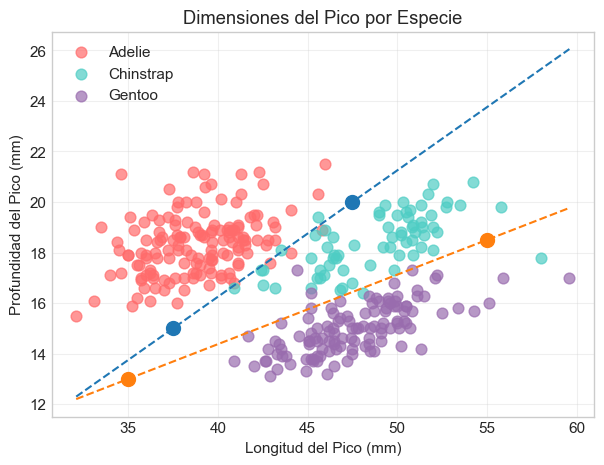

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7, 5))

for species in df['species'].unique():
    subset = df[df['species'] == species]
    ax.scatter(subset['bill_length_mm'],
               subset['bill_depth_mm'],
               c=COLORES_ESPECIES[species],
               label=species,
               alpha=0.7,
               s=60)

ax.set_xlabel('Longitud del Pico (mm)')
ax.set_ylabel('Profundidad del Pico (mm)')
ax.set_title('Dimensiones del Pico por Especie')
ax.legend()
ax.grid(True, alpha=0.3)

# Linea 1
x1, y1 = 37.5, 15
x2, y2 = 47.5, 20

m = (y2 - y1) / (x2 - x1)

x_vals = np.linspace(df['bill_length_mm'].min(),
                     df['bill_length_mm'].max(),
                     100)

y_vals = m * (x_vals - x1) + y1

ax.plot(x_vals, y_vals, linestyle='--')

ax.scatter([x1, x2], [y1, y2], s=100)

# Linea 2
x3, y3 = 35, 13
x4, y4 = 55, 18.5

m2 = (y4 - y3) / (x4 - x3)

x_vals2 = np.linspace(df['bill_length_mm'].min(),
                     df['bill_length_mm'].max(),
                     100)

y_vals2 = m2 * (x_vals2 - x3) + y3

ax.plot(x_vals2, y_vals2, linestyle='--')

ax.scatter([x3, x4], [y3, y4], s=100)

plt.show()

---

# PARTE 2: Diseño de Reglas de Clasificación (25 puntos)

## 🧠 Tu Turno: Crea las Reglas

Ahora que exploraste los datos, es momento de **pensar como un experto** y diseñar reglas para clasificar pingüinos.

### Ejemplo de Regla

```python
# Ejemplo (puede no ser óptimo):
if flipper_length_mm > 210:
    return "Gentoo"
elif bill_length_mm > 45:
    return "Chinstrap"
else:
    return "Adelie"
```

### Tu Tarea

1. Observa las gráficas anteriores cuidadosamente
2. Identifica **umbrales** (valores límite) que separen las especies
3. Diseña tu conjunto de reglas
4. Documenta tu razonamiento

### Ejercicio 2.1: Documenta tu Estrategia (10 puntos)

Antes de codificar, explica tu estrategia:

**Responde aquí:**

1. ¿Qué variable(s) usarás para separar primero una especie de las otras?
   - *Tu respuesta:* Ocuparé longitud y profundidad del pico, pues en la grafica de dispersión se observa que separa los datos de forma un tanto precisa

2. ¿Qué umbral(es) numérico(s) planeas usar? (ej: "si aleta > 210")
   - Planeo ocupar dos rectas que dividan el plano en tres para así obtener una mejor aproximación con valores que minimicen los errores, con los siguientes valores: 
   Si bill_depth_mm > 0.5 * bill_length_mm - 3.75
   y bill_depth_mm < 0.275 * bill_length_mm + 3.375

3. ¿Cuál especie crees que será más fácil de identificar? ¿Por qué?
   - La especie que menos se solapa con las demás que es la Adelie, pues esta tiene menos valores solapados que las demás

4. ¿Cuál especie crees que será más difícil? ¿Por qué?
   -  La especie más dificil sería Chinstrap pues los valores del pico siempre terminan solapando tanto con Adelie como con Gentoo

### Ejercicio 2.2: Implementa tu Clasificador Humano (15 puntos)

Completa la función `clasificador_humano()` con TUS propias reglas.

**Reglas del juego:**
- Solo puedes usar las 4 variables numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
- NO puedes usar la isla (sería trampa, ya que ciertas especies solo viven en ciertas islas)
- Puedes usar tantas reglas if/elif/else como quieras
- La función debe retornar: `'Adelie'`, `'Chinstrap'`, o `'Gentoo'`

In [9]:
def clasificador_humano(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):
    """
    Clasifica un pingüino basándose en reglas diseñadas por un humano.
    
    Parámetros:
    -----------
    bill_length_mm : float
        Longitud del pico en milímetros
    bill_depth_mm : float
        Profundidad del pico en milímetros
    flipper_length_mm : float
        Longitud de la aleta en milímetros
    body_mass_g : float
        Masa corporal en gramos
        
    Retorna:
    --------
    str : 'Adelie', 'Chinstrap', o 'Gentoo'
    """
    
    # ═══════════════════════════════════════════════════════════════════════
    # TU CÓDIGO AQUÍ: Implementa tus reglas de clasificación
    # ═══════════════════════════════════════════════════════════════════════
    
    # Ejemplo (reemplaza con tus propias reglas):
    # if flipper_length_mm > ???:
    #     return "Gentoo"
    # elif bill_length_mm > ???:
    #     return "Chinstrap"
    # else:
    #     return "Adelie"
    
    # TU CÓDIGO:


    
# Valor de cada recta en ese x
    # Línea 1
    x1, y1 = 37.5, 15
    x2, y2 = 47.5, 20
    m1 = (y2 - y1) / (x2 - x1)

    # Línea 2
    x3, y3 = 35, 13
    x4, y4 = 55, 18.5
    m2 = (y4 - y3) / (x4 - x3)

    y_recta1 = m1 * (bill_length_mm - x1) + y1
    y_recta2 = m2 * (bill_length_mm - x3) + y3
    
    if bill_depth_mm > y_recta1:
        return "Adelie"
    
    elif bill_depth_mm < y_recta2:
        return "Gentoo"
    else:
        return "Chinstrap"

In [10]:
# Prueba rápida de tu clasificador con algunos ejemplos
print("🧪 Prueba de tu clasificador humano:")
print("="*60)

# Casos de prueba (valores típicos de cada especie)
casos_prueba = [
    # [bill_length, bill_depth, flipper_length, body_mass, especie_real]
    [39.1, 18.7, 181, 3750, "Adelie"],
    [46.5, 17.9, 192, 3500, "Chinstrap"],
    [46.1, 13.2, 211, 4500, "Gentoo"],
]

print(f"{'Pico L':>8} {'Pico D':>8} {'Aleta':>8} {'Masa':>8} │ {'Real':>12} {'Tu Pred':>12} {'¿Correcto?':>12}")
print("-" * 80)

for caso in casos_prueba:
    pred = clasificador_humano(caso[0], caso[1], caso[2], caso[3])
    real = caso[4]
    correcto = "✅" if pred == real else "❌"
    print(f"{caso[0]:>8.1f} {caso[1]:>8.1f} {caso[2]:>8} {caso[3]:>8} │ {real:>12} {str(pred):>12} {correcto:>12}")

🧪 Prueba de tu clasificador humano:
  Pico L   Pico D    Aleta     Masa │         Real      Tu Pred   ¿Correcto?
--------------------------------------------------------------------------------
    39.1     18.7      181     3750 │       Adelie       Adelie            ✅
    46.5     17.9      192     3500 │    Chinstrap    Chinstrap            ✅
    46.1     13.2      211     4500 │       Gentoo       Gentoo            ✅


---

# PARTE 3: Evaluación del Clasificador Humano (20 puntos)

## 📊 ¿Qué tan bueno es tu clasificador?

Ahora evaluaremos tu clasificador con **todos los datos de prueba**.

### Ejercicio 3.1: Prepara los Datos (5 puntos)

Divide el dataset en entrenamiento (80%) y prueba (20%).

In [11]:
from sklearn.model_selection import train_test_split
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

# TU CÓDIGO AQUÍ: Divide los datos en train y test
# Usa test_size=0.2, random_state=42, stratify=y

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Verifica tu división:
print(f"📊 División de datos:")
print(f"   Entrenamiento: {len(X_train)} pingüinos")
print(f"   Prueba: {len(X_test)} pingüinos")

📊 División de datos:
   Entrenamiento: 266 pingüinos
   Prueba: 67 pingüinos


### Ejercicio 3.2: Evalúa tu Clasificador (15 puntos)

Aplica tu clasificador a todos los datos de prueba y calcula el accuracy.

In [12]:
from sklearn.metrics import accuracy_score
# Aplicar tu clasificador a todos los datos de prueba
predicciones_humano = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano(
        row['bill_length_mm'],
        
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano.append(pred)

# TU CÓDIGO AQUÍ: Calcula el accuracy de tu clasificador
# Pista: usa accuracy_score(y_test, predicciones_humano)

accuracy_humano = accuracy_score(y_test, predicciones_humano)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠            ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_humano:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_humano * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║           🧠 RESULTADOS DEL CLASIFICADOR HUMANO 🧠            ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 97.01%                                       ║
║   Aciertos: 65 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Clasificador Humano:


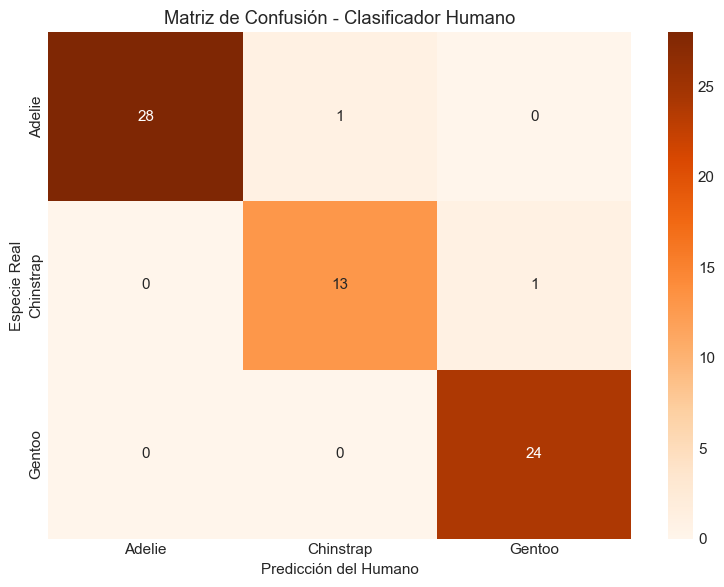


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      0.93      0.93        14
      Gentoo       0.96      1.00      0.98        24

    accuracy                           0.97        67
   macro avg       0.96      0.96      0.96        67
weighted avg       0.97      0.97      0.97        67



In [13]:
# Matriz de confusión de tu clasificador
print("\n📋 Matriz de Confusión - Clasificador Humano:")
print("="*50)

cm_humano = confusion_matrix(y_test, predicciones_humano, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Humano')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Clasificador Humano')
plt.tight_layout()
plt.savefig('confusion_humano.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_humano))

**Reflexiona sobre tus resultados:**

1. ¿Qué especie clasificaste mejor?
   - Adelie

2. ¿Qué especie te dio más problemas? ¿Por qué crees que pasó?
   - Chinstrap porque sus valores se solapan mucho en comparación con otros

3. ¿Cuántos pingüinos clasificaste incorrectamente?
   - 2, uno se clasificó como Gentoo siendo chinstrap, y el otro se clasificó Chinstrap siendo Adelie 

---

# PARTE 4: El Clasificador de Machine Learning (20 puntos)

## 🤖 Ahora le toca a la Máquina

Entrenaremos un **Árbol de Decisión** (el mismo algoritmo que vimos en clase) y veremos cómo le va.

### Ejercicio 4.1: Entrena el Modelo (10 puntos)

Crea y entrena un `DecisionTreeClassifier`.

In [14]:
# TU CÓDIGO AQUÍ: Crea y entrena un DecisionTreeClassifier

# 1. Crea el modelo (usa random_state=42 para reproducibilidad)
modelo_ml = DecisionTreeClassifier(random_state=42)


# 2. Entrena el modelo con los datos de entrenamiento
modelo_ml.fit(X_train, y_train)


print("✅ Modelo de Machine Learning entrenado!")
print(f"   Profundidad del árbol: {modelo_ml.get_depth()}")
print(f"   Número de hojas: {modelo_ml.get_n_leaves()}")

✅ Modelo de Machine Learning entrenado!
   Profundidad del árbol: 5
   Número de hojas: 11


### Ejercicio 4.2: Evalúa el Modelo ML (10 puntos)

Haz predicciones y calcula el accuracy.

In [15]:
# TU CÓDIGO AQUÍ: Haz predicciones con el modelo ML

# 1. Predice las especies para X_test
predicciones_ml = modelo_ml.predict(X_test)


# 2. Calcula el accuracy
accuracy_ml = accuracy_score(y_test, predicciones_ml)


print("╔═══════════════════════════════════════════════════════════════╗")
print("║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Accuracy: {accuracy_ml:.2%}                                       ║")
print(f"║   Aciertos: {int(accuracy_ml * len(y_test))} de {len(y_test)} pingüinos                           ║")
print("╚═══════════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════════╗
║         🤖 RESULTADOS DEL CLASIFICADOR ML 🤖                  ║
╠═══════════════════════════════════════════════════════════════╣
║   Accuracy: 95.52%                                       ║
║   Aciertos: 64 de 67 pingüinos                           ║
╚═══════════════════════════════════════════════════════════════╝



📋 Matriz de Confusión - Modelo ML:


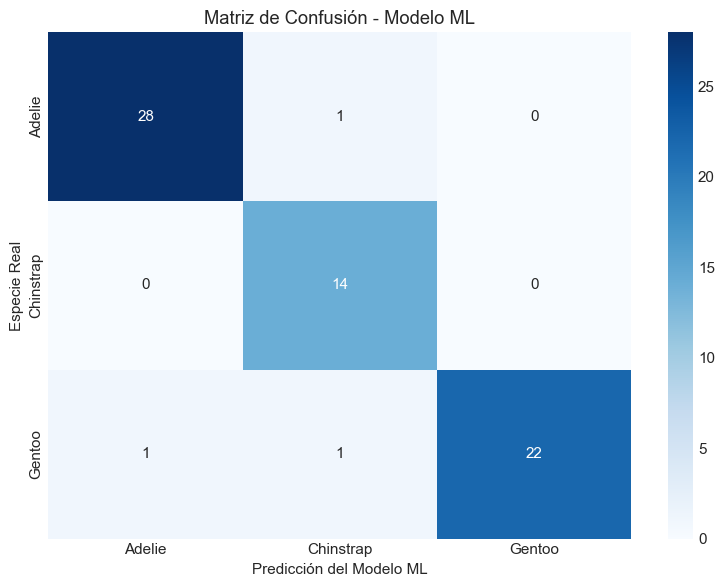


📊 Reporte Detallado:
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        29
   Chinstrap       0.88      1.00      0.93        14
      Gentoo       1.00      0.92      0.96        24

    accuracy                           0.96        67
   macro avg       0.95      0.96      0.95        67
weighted avg       0.96      0.96      0.96        67



In [16]:
# Matriz de confusión del modelo ML
print("\n📋 Matriz de Confusión - Modelo ML:")
print("="*50)

cm_ml = confusion_matrix(y_test, predicciones_ml, labels=['Adelie', 'Chinstrap', 'Gentoo'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adelie', 'Chinstrap', 'Gentoo'],
            yticklabels=['Adelie', 'Chinstrap', 'Gentoo'])
plt.xlabel('Predicción del Modelo ML')
plt.ylabel('Especie Real')
plt.title('Matriz de Confusión - Modelo ML')
plt.tight_layout()
plt.savefig('confusion_ml.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Reporte Detallado:")
print(classification_report(y_test, predicciones_ml))

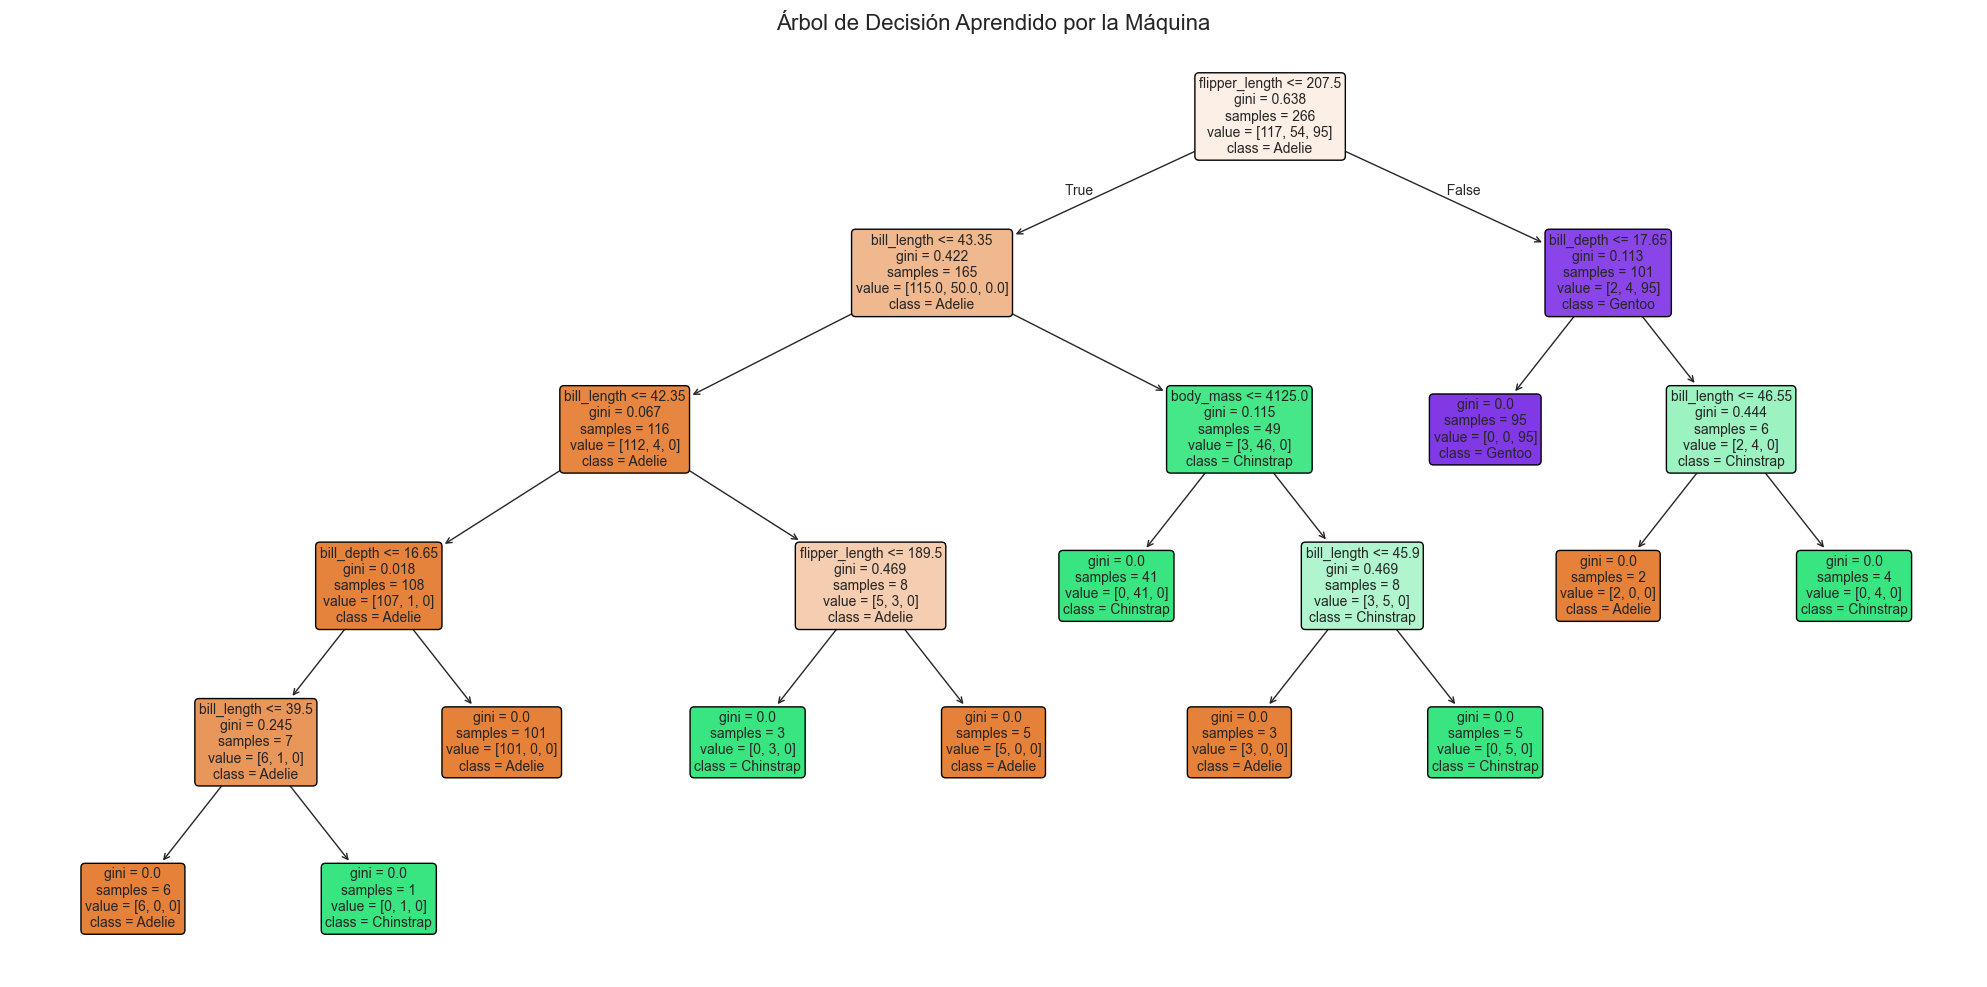


💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.
   ¿Son similares a las tuyas? ¿Usó las mismas variables?


In [17]:
# Visualiza las reglas que aprendió la máquina
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_ml,
    feature_names=['bill_length', 'bill_depth', 'flipper_length', 'body_mass'],
    class_names=['Adelie', 'Chinstrap', 'Gentoo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de Decisión Aprendido por la Máquina', fontsize=16)
plt.tight_layout()
plt.savefig('arbol_pinguinos.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Observa: Estas son las reglas que la MÁQUINA descubrió automáticamente.")
print("   ¿Son similares a las tuyas? ¿Usó las mismas variables?")

In [18]:
import pickle
from sklearn.tree import DecisionTreeClassifier

modelo_ml = DecisionTreeClassifier(random_state=42)
modelo_ml.fit(X_train, y_train)

with open("modelo_penguins.pkl", "wb") as f:
    pickle.dump(modelo_ml, f)

---

# PARTE 5: La Batalla Final (20 puntos)

## ⚔️ Humano vs Máquina: ¿Quién Gana?

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# COMPARACIÓN FINAL
# ═══════════════════════════════════════════════════════════════════════════

print("")
print("╔═══════════════════════════════════════════════════════════════════════════╗")
print("║                                                                           ║")
print("║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")
print("║                                                                           ║")
print(f"║   🧠 CLASIFICADOR HUMANO:     {accuracy_humano:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_humano * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print(f"║   🤖 CLASIFICADOR ML:         {accuracy_ml:.2%} accuracy                         ║")
print(f"║      Aciertos: {int(accuracy_ml * len(y_test)):2d}/{len(y_test)} pingüinos                                      ║")
print("║                                                                           ║")
print("╠═══════════════════════════════════════════════════════════════════════════╣")

diferencia = accuracy_ml - accuracy_humano

if diferencia > 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: LA MÁQUINA 🏆                             ║")
    print(f"║                     Ventaja: +{diferencia:.2%}                                    ║")
    print("║                                                                           ║")
elif diferencia < 0:
    print("║                                                                           ║")
    print("║                     🏆 GANADOR: EL HUMANO 🏆                              ║")
    print(f"║                     Ventaja: +{-diferencia:.2%}                                   ║")
    print("║                                                                           ║")
else:
    print("║                                                                           ║")
    print("║                        🤝 EMPATE TÉCNICO 🤝                               ║")
    print("║                                                                           ║")

print("╚═══════════════════════════════════════════════════════════════════════════╝")


╔═══════════════════════════════════════════════════════════════════════════╗
║                                                                           ║
║            ⚔️  BATALLA FINAL: HUMANO VS MÁQUINA ⚔️                        ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   🧠 CLASIFICADOR HUMANO:     97.01% accuracy                         ║
║      Aciertos: 65/67 pingüinos                                      ║
║                                                                           ║
║   🤖 CLASIFICADOR ML:         95.52% accuracy                         ║
║      Aciertos: 64/67 pingüinos                                      ║
║                                                                           ║
╠═══════════════════════════════════════════════════════════════════════════╣
║      

C:\Users\ramir\AppData\Local\Temp\ipykernel_15244\3931004592.py:32: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\ramir\AppData\Local\Temp\ipykernel_15244\3931004592.py:33: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
c:\Users\ramir\Documents\ESCOM\SextoSemestre\sextoSemestre\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128039 (\N{PENGUIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


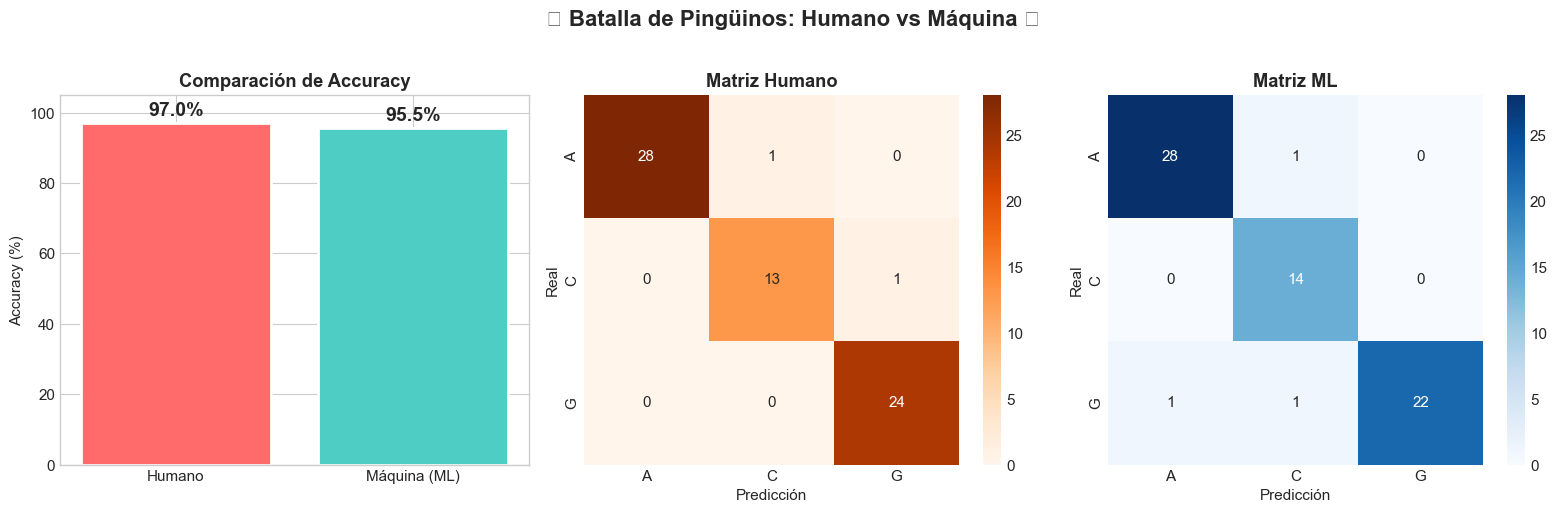

In [20]:
# Gráfica comparativa
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Barras de accuracy
clasificadores = ['Humano', 'Máquina (ML)']
accuracies = [accuracy_humano * 100, accuracy_ml * 100]
colores_barras = ['#FF6B6B', '#4ECDC4']

bars = axes[0].bar(clasificadores, accuracies, color=colores_barras, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Comparación de Accuracy', fontweight='bold')
axes[0].set_ylim(0, 105)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Gráfica 2: Matrices de confusión lado a lado (Humano)
sns.heatmap(cm_humano, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[1].set_title('Matriz Humano', fontweight='bold')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Gráfica 3: Matriz ML
sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['A', 'C', 'G'], yticklabels=['A', 'C', 'G'])
axes[2].set_title('Matriz ML', fontweight='bold')
axes[2].set_xlabel('Predicción')
axes[2].set_ylabel('Real')

plt.suptitle('🐧 Batalla de Pingüinos: Humano vs Máquina 🐧', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('batalla_final.png', dpi=150, bbox_inches='tight')
plt.show()

### Ejercicio 5.1: Análisis de Errores (10 puntos)

Identifica los casos donde cada clasificador falló.

In [21]:
# Crear DataFrame con resultados
resultados = X_test.copy()
resultados['especie_real'] = y_test.values
resultados['pred_humano'] = predicciones_humano
resultados['pred_ml'] = predicciones_ml
resultados['error_humano'] = resultados['especie_real'] != resultados['pred_humano']
resultados['error_ml'] = resultados['especie_real'] != resultados['pred_ml']

# Mostrar errores del humano
errores_humano = resultados[resultados['error_humano']]
print(f"❌ Errores del clasificador HUMANO ({len(errores_humano)} casos):")
print("="*80)
if len(errores_humano) > 0:
    print(errores_humano[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                          'body_mass_g', 'especie_real', 'pred_humano']].to_string())
else:
    print("¡Ningún error! 🎉")

❌ Errores del clasificador HUMANO (2 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real pred_humano
75             42.9           17.6              196.0       4700.0       Adelie   Chinstrap
196            48.1           16.4              199.0       3325.0    Chinstrap      Gentoo


In [22]:
# Mostrar errores de la máquina
errores_ml = resultados[resultados['error_ml']]
print(f"\n❌ Errores del clasificador ML ({len(errores_ml)} casos):")
print("="*80)
if len(errores_ml) > 0:
    print(errores_ml[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 
                      'body_mass_g', 'especie_real', 'pred_ml']].to_string())
else:
    print("¡Ningún error! 🎉")


❌ Errores del clasificador ML (3 casos):
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g especie_real    pred_ml
245            45.1           14.5              207.0       5050.0       Gentoo     Adelie
14             46.0           21.5              194.0       4200.0       Adelie  Chinstrap
310            48.4           14.4              203.0       4625.0       Gentoo  Chinstrap


### Ejercicio 5.2: Reflexión Final (10 puntos)

**Responde las siguientes preguntas basándote en tus resultados:**

1. **¿Quién ganó la batalla y por cuánto?**
   - Con la semilla sentada en 42 el humano ganó por 1.49% equivocandose en uno menos que la máquina

2. **¿Qué errores cometiste que la máquina no cometió?** (o viceversa)
   - En mi frontera de decisión me equivoque en los patrones 75 y 196, en cambio la máquina se equivocó en 245, 14 y 310

3. **¿Las reglas del árbol de decisión se parecen a las tuyas?** ¿Usó las mismas variables?
   - No ocupamos diferentes umbrales para las 4 variables

4. **¿Cuál es la principal ventaja de usar Machine Learning sobre reglas manuales?**
   - Que es de manera automática en cambio para el sistema experto una persona debe analizar los datos y obtener los umbrales que den mejores resultados por prueba y error llevando mucho más tiempo que entrenar un modelo. 

5. **¿Qué harías diferente si pudieras volver a diseñar tus reglas?**
   - Agregaría nuevos umbrales y haría un bagging para hacer una votación entre diferentes clasificadores para mejorar la predicción 

---

# BONUS: Mejora tu Clasificador (+10 puntos)

## 🔄 Segunda Oportunidad

Ahora que viste dónde fallaste y qué reglas encontró la máquina, ¿puedes mejorar tu clasificador?

**Requisitos para el bonus:**
1. Crea una versión mejorada de `clasificador_humano()`
2. Explica qué cambios hiciste y por qué
3. Demuestra que el accuracy mejoró

In [23]:
def clasificador_humano_v2(bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g):

    from collections import Counter
    import random

    votos = []

    # --- Clasificador 1 (tu clasificador original con rectas) ---
    x1, y1 = 37.5, 15
    x2, y2 = 47.5, 20
    m1 = (y2 - y1) / (x2 - x1)

    x3, y3 = 35, 13
    x4, y4 = 55, 18.5
    m2 = (y4 - y3) / (x4 - x3)

    y_recta1 = m1 * (bill_length_mm - x1) + y1
    y_recta2 = m2 * (bill_length_mm - x3) + y3

    if bill_depth_mm > y_recta1:
        votos.append("Adelie")
    elif bill_depth_mm < y_recta2:
        votos.append("Gentoo")
    else:
        votos.append("Chinstrap")


    
    if flipper_length_mm > 205:
        votos.append("Gentoo")
    elif bill_depth_mm > 0.5 * bill_length_mm - 4:
        votos.append("Adelie")
    else:
        votos.append("Chinstrap")



    if flipper_length_mm > 210:
        votos.append("Gentoo")
    elif bill_length_mm > 45:
        votos.append("Chinstrap")
    else:
        votos.append("Adelie")



    conteo = Counter(votos)
    max_votos = max(conteo.values())

    candidatos = [k for k, v in conteo.items() if v == max_votos]

    # Si hay empate, usar el primer clasificador
    if len(candidatos) > 1:
        return votos[0]

    return candidatos[0]

In [24]:
# Evalúa tu clasificador mejorado
predicciones_humano_v2 = []

for idx, row in X_test.iterrows():
    pred = clasificador_humano_v2(
        row['bill_length_mm'],
        row['bill_depth_mm'],
        row['flipper_length_mm'],
        row['body_mass_g']
    )
    predicciones_humano_v2.append(pred)

print("Clases reales:", set(y_test))
print("Clases predichas:", set(predicciones_humano_v2))
accuracy_humano_v2 = accuracy_score(y_test, predicciones_humano_v2)

print("╔═══════════════════════════════════════════════════════════════╗")
print("║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║")
print("╠═══════════════════════════════════════════════════════════════╣")
print(f"║   Versión 1: {accuracy_humano:.2%}                                         ║")
print(f"║   Versión 2: {accuracy_humano_v2:.2%}                                         ║")
print(f"║   Mejora:    {(accuracy_humano_v2 - accuracy_humano):.2%}                                         ║")
print("╚═══════════════════════════════════════════════════════════════╝")

if accuracy_humano_v2 > accuracy_humano:
    print("\n🎉 ¡Excelente! Tu clasificador mejoró.")
else:
    print("\n🤔 Hmm, no hubo mejora. ¿Puedes intentar otros cambios?")

Clases reales: {'Chinstrap', 'Gentoo', 'Adelie'}
Clases predichas: {'Chinstrap', 'Gentoo', 'Adelie'}
╔═══════════════════════════════════════════════════════════════╗
║        📈 RESULTADOS DEL CLASIFICADOR MEJORADO 📈             ║
╠═══════════════════════════════════════════════════════════════╣
║   Versión 1: 97.01%                                         ║
║   Versión 2: 98.51%                                         ║
║   Mejora:    1.49%                                         ║
╚═══════════════════════════════════════════════════════════════╝

🎉 ¡Excelente! Tu clasificador mejoró.


**Explica qué cambios hiciste y por qué:**

Realice un bagging con tres diferentes clasificadores para así mejorar la precisión del modelo, observe que para la clase Chinstrap, mi clasificador fallaba, dentro de la línea de decisión, entonces busque una forma en la que mitigar ese error y aplique el tamaño de la aleta como divisor, además agregue otra forma de clasificador de igual forma usando la longitud del ala, una vez que los tres votaran, se elige el que tenga una mayor cantidad de votos o en caso de empate, se retorna el valor de mi primer clasificador.



---

# 📝 Entrega Final

## Checklist de Entrega

Antes de entregar, verifica que completaste todo:

- [ ] **Parte 1:** Estadísticas básicas y por especie calculadas
- [ ] **Parte 2:** Estrategia documentada y función `clasificador_humano()` implementada
- [ ] **Parte 3:** Datos divididos y accuracy del clasificador humano calculado
- [ ] **Parte 4:** Modelo ML entrenado y evaluado
- [ ] **Parte 5:** Análisis comparativo y reflexión final completados
- [ ] **Bonus (opcional):** Clasificador mejorado con explicación

## Criterios de Evaluación

| Criterio | Puntos |
|----------|--------|
| Código funcional y sin errores | 30 |
| Respuestas reflexivas y bien argumentadas | 30 |
| Exploración correcta de datos | 15 |
| Clasificador humano creativo y razonado | 15 |
| Presentación y claridad | 10 |
| **Total** | **100** |

---

## 🎓 Lección Aprendida

Este reto demuestra la diferencia fundamental entre:

**Programación Tradicional:**
- TÚ diseñas las reglas
- Requiere conocimiento experto del dominio
- Difícil capturar patrones complejos
- Las reglas pueden ser subjetivas

**Machine Learning:**
- La MÁQUINA descubre las reglas
- Aprende de los datos
- Puede encontrar patrones que los humanos no ven
- Objetiva y reproducible

```
     HUMANO                              MÁQUINA
    ════════                            ═════════
                                        
   "Creo que si                      datos ──► algoritmo ──► reglas
    el pico es                       
    largo..."                        "Encontré que flipper_length
                                      ≤ 206.5 separa Gentoo con
   Basado en                          98.3% de confianza"
   intuición                         
                                      Basado en DATOS
```

**¡Bienvenido/a al mundo del Machine Learning!** 🚀

---

*Reto 1 - Humano vs Máquina | Modelado Predictivo 2026*